# 안전재고율에 따른 재고 비용 최적화

사용 데이터: [UCI: Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)

- 판매량을 관측된 수요라고 간주

In [2]:
import pandas as pd

df = pd.read_excel("/content/Online Retail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. 일별 SKU별 판매량 정리

1. C로 시작하는 InvoiceNo는 취소 거래로 정의하여 제외
2. 그 외 음수 Quantity는 반품으로 간주하여 정상 판매량에서 차감하여 순판매량(Net Sales) 산출
3. 이후 SKU X 일 단위로 Quantity를 합산하여 순판매량(Net Sales)을 산출한다.

In [4]:
# 1. 취소거래 제외
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 2. SKU x 날짜별 순판매량 계산
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Date"] = df["InvoiceDate"].dt.date

sku_daily_sales = (
    df.groupby(["StockCode", "Date"], as_index=False)["Quantity"]
      .sum()
      .rename(columns={"Quantity": "NetSales"})
)

# [중요] 거래가 없는 날짜는 순판매량 0
sku_daily_sales["Date"] = pd.to_datetime(sku_daily_sales["Date"])
date_range = pd.date_range(
    sku_daily_sales["Date"].min(),
    sku_daily_sales["Date"].max(),
    freq="D"
)
sku_date = pd.MultiIndex.from_product(
    [sku_daily_sales["StockCode"].unique(), date_range],
    names=["StockCode", "Date"]
).to_frame(index=False)
sku_daily_sales = sku_date.merge(
    sku_daily_sales,
    on=["StockCode", "Date"],
    how="left"
)
sku_daily_sales["NetSales"] = sku_daily_sales["NetSales"].fillna(0)
sku_daily_sales = sku_daily_sales.sort_values(
    ["StockCode", "Date"]
).reset_index(drop=True)

In [5]:
sku_daily_sales

,StockCode,Date,NetSales
0,10002,2010-12-01,60.0
1,10002,2010-12-02,1.0
2,10002,2010-12-03,8.0
3,10002,2010-12-04,0.0
4,10002,2010-12-05,1.0
...,...,...,...
1518061,m,2011-12-05,0.0
1518062,m,2011-12-06,0.0
1518063,m,2011-12-07,0.0
1518064,m,2011-12-08,0.0


## 2. 주간 SKU별 판매량 정리

In [6]:
iso_calendar = sku_daily_sales["Date"].dt.isocalendar()

sku_daily_sales["Year"] = iso_calendar.year
sku_daily_sales["Week"] = iso_calendar.week

# 연도-주차 생성
sku_daily_sales["YearWeek"] = (
    sku_daily_sales["Year"].astype(str)
    + "-W"
    + sku_daily_sales["Week"].astype(str).str.zfill(2)
)

# SKU x 연도 x 주차별 순판매량
sku_weekly_sales = (
    sku_daily_sales
    .groupby(["StockCode", "Year", "Week", "YearWeek"], as_index=False)["NetSales"]
    .sum()
)

In [7]:
sku_weekly_sales

,StockCode,Year,Week,YearWeek,NetSales
0,10002,2010,48,2010-W48,70.0
1,10002,2010,49,2010-W49,138.0
2,10002,2010,50,2010-W50,41.0
3,10002,2010,51,2010-W51,2.0
4,10002,2010,52,2010-W52,0.0
...,...,...,...,...,...
219181,m,2011,45,2011-W45,0.0
219182,m,2011,46,2011-W46,0.0
219183,m,2011,47,2011-W47,0.0
219184,m,2011,48,2011-W48,0.0


## 3. 가공 데이터가 예측에 용이한 지 판단

### 3-1. 판매량이 0인 주차의 비율이 적었으면 함

In [8]:
sku_summary = (
    sku_weekly_sales
    .groupby("StockCode")["NetSales"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
        zero_ratio=lambda x: (x == 0).mean()
    )
    .reset_index()
)

sku_summary.head(10)

,StockCode,mean,std,min,max,zero_ratio
0,10002,19.203704,50.620072,-3.0,306.0,0.629630
1,10080,9.166667,27.095742,0.0,182.0,0.703704
2,10120,3.574074,8.010846,0.0,38.0,0.629630
3,10125,24.000000,38.604917,0.0,197.0,0.333333
4,10133,51.574074,77.889763,-82.0,245.0,0.333333
5,10134,-0.351852,2.585573,-19.0,0.0,0.981481
6,10135,41.314815,66.711382,0.0,306.0,0.111111
7,11001,29.907407,56.019629,0.0,385.0,0.166667
8,15030,5.425926,22.045067,0.0,150.0,0.796296
9,15034,122.055556,250.739165,0.0,1272.0,0.111111


In [9]:
negative_weekly = sku_weekly_sales[
    sku_weekly_sales["NetSales"] < 0
]

print("음수 주간 판매량:", len(negative_weekly))
print("비율:", len(negative_weekly) / len(sku_weekly_sales))

음수 주간 판매량: 1068
비율: 0.004872573978265035


### 3-2. 판매량이 0인 주차의 비율이 전체의 30% 이하, 전체 판매 주차수가 40주차 이상, 평균 판매량이 5 단위 이상

In [10]:
sku_summary = (
    sku_weekly_sales
    .groupby("StockCode")["NetSales"]
    .agg(
        mean="mean",
        std="std",
        zero_ratio=lambda x: (x == 0).mean(),
        weeks="count"
    )
    .reset_index()
)

target_skus = sku_summary[
    (sku_summary["zero_ratio"] <= 0.3) &
    (sku_summary["weeks"] >= 40) &
    (sku_summary["mean"] >= 5)
]["StockCode"]

print("전체 SKU:", sku_summary["StockCode"].nunique())
print("예측 대상 SKU:", target_skus.nunique())

sku_weekly_sales_target = sku_weekly_sales[
    sku_weekly_sales["StockCode"].isin(target_skus)
].copy().reset_index(drop=True)
print(f"후보: {sku_weekly_sales_target['StockCode'].unique()}")

전체 SKU: 4059
예측 대상 SKU: 1145
후보: [10135 11001 15034 ... 'DOT' 'M' 'POST']


$\rightarrow$ 최종 분석은 10135 11001 15034 품목을 대상으로 함

## 4. 분석 대상 데이터만 추출

In [11]:
target_skus = [10135, 11001, 15034]

target_data = sku_weekly_sales[
    sku_weekly_sales["StockCode"].isin(target_skus)
].copy().reset_index(drop=True)

target_data.head()

,StockCode,Year,Week,YearWeek,NetSales
0,10135,2010,48,2010-W48,23.0
1,10135,2010,49,2010-W49,28.0
2,10135,2010,50,2010-W50,306.0
3,10135,2010,51,2010-W51,54.0
4,10135,2010,52,2010-W52,0.0


In [12]:
target_data.groupby("StockCode")["NetSales"].agg(
    mean="mean",
    std="std",
    zero_ratio=lambda x: (x == 0).mean()
)

,mean,std,zero_ratio
StockCode,,,
10135,41.314815,66.711382,0.111111
11001,29.907407,56.019629,0.166667
15034,122.055556,250.739165,0.111111


- zero_ratio는 약 15% 이내로 낮음을 확인
- 표준편차는 60, 혹은 250이므로 상당히 크다는 것을 확인할 수 있음

In [13]:
target_data = target_data.sort_values(
    ["StockCode", "Year", "Week"]
)

target_data.head(20)

,StockCode,Year,Week,YearWeek,NetSales
0,10135,2010,48,2010-W48,23.0
1,10135,2010,49,2010-W49,28.0
2,10135,2010,50,2010-W50,306.0
3,10135,2010,51,2010-W51,54.0
4,10135,2010,52,2010-W52,0.0
5,10135,2011,1,2011-W01,225.0
6,10135,2011,2,2011-W02,116.0
7,10135,2011,3,2011-W03,260.0
8,10135,2011,4,2011-W04,12.0
9,10135,2011,5,2011-W05,1.0


In [14]:
def add_weekly_features(target_data, df):
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    # ISO 연도 / 주차
    iso_calendar = df["InvoiceDate"].dt.isocalendar()

    df["Year"] = iso_calendar.year
    df["Week"] = iso_calendar.week

    # 3개 SKU에 해당하는 거래만 사용
    target_df = df[
        df["StockCode"].isin(target_data["StockCode"].unique())
    ].copy()

    # SKU × 주별 Feature 생성
    weekly_features = (
        target_df
        .groupby(["StockCode", "Year", "Week"])
        .agg(
            AvgUnitPrice=("UnitPrice", "mean"),
            CustomerCount=("CustomerID", "nunique"),
            TransactionCount=("InvoiceNo", "nunique")
        )
        .reset_index()
    )

    # target_data에 조인
    target_data = target_data.merge(
        weekly_features,
        on=["StockCode", "Year", "Week"],
        how="left"
    )

    return target_data

In [15]:
target_data = add_weekly_features(target_data, df)
target_data = target_data.dropna() # AvgUnitPrice, CustomerCount, TransactionCount 연산 결과에 결측이 있는 경우 제거

In [16]:
target_data

,StockCode,Year,Week,YearWeek,NetSales,AvgUnitPrice,CustomerCount,TransactionCount
0,10135,2010,48,2010-W48,23.0,1.754000,3.0,5.0
1,10135,2010,49,2010-W49,28.0,2.037500,3.0,8.0
2,10135,2010,50,2010-W50,306.0,1.063077,9.0,13.0
3,10135,2010,51,2010-W51,54.0,1.594000,2.0,5.0
5,10135,2011,1,2011-W01,225.0,0.883077,6.0,13.0
...,...,...,...,...,...,...,...,...
157,15034,2011,45,2011-W45,28.0,0.554000,2.0,5.0
158,15034,2011,46,2011-W46,20.0,0.554000,2.0,5.0
159,15034,2011,47,2011-W47,112.0,0.140000,5.0,5.0
160,15034,2011,48,2011-W48,16.0,0.600000,1.0,3.0


## 5. 파생변수 생성 및 학습/평가 데이터 분할

### 5-1. 파생변수 목록
- 다음 주 수요 (target)
- 과거 판매량 1, 2, 3, 4
- 과거 4주 평균 판매량
- 과거 4주 판매량 표준편차
- 지난 주 AvgUnitPrice, CustomerCount, TransactionCount
- 판매 월

In [17]:
def prepare_forecasting_data(target_data, test_size=0.2):
    target_data = target_data.sort_values(
        ["Year", "Week", "StockCode"]
    ).copy()

    # 다음 주 수요(Target)
    target_data["NextWeekSales"] = (
        target_data
        .groupby("StockCode")["NetSales"]
        .shift(-1)
    )

    # 과거 판매량 Lag
    for lag in [1, 2, 3, 4]:
        target_data[f"lag_{lag}"] = (
            target_data
            .groupby("StockCode")["NetSales"]
            .shift(lag)
        )

    # 과거 4주 평균
    target_data["rolling_mean_4"] = (
        target_data
        .groupby("StockCode")["NetSales"]
        .transform(
            lambda x: x.shift(1).rolling(4).mean()
        )
    )

    # 과거 4주 표준편차
    target_data["rolling_std_4"] = (
        target_data
        .groupby("StockCode")["NetSales"]
        .transform(
            lambda x: x.shift(1).rolling(4).std()
        )
    )

    # 주간 Feature의 직전 주 값
    for col in [
        "AvgUnitPrice",
        "CustomerCount",
        "TransactionCount"
    ]:
        target_data[f"{col}_lag1"] = (
            target_data
            .groupby("StockCode")[col]
            .shift(1)
        )

    # 계절성 Feature
    target_data["Month"] = (
        pd.to_datetime(
            target_data["YearWeek"] + "-1",
            format="%G-W%V-%u"
        ).dt.month
    )

    # 모델에 사용할 Feature
    feature_columns = [
        "StockCode",
        "Week",
        "Month",
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_4",
        "rolling_mean_4",
        "rolling_std_4",
        "AvgUnitPrice_lag1",
        "CustomerCount_lag1",
        "TransactionCount_lag1"
    ]

    target_column = "NextWeekSales"

    # 모델 데이터 생성
    model_data = target_data[
        feature_columns + [target_column]
    ].dropna().copy()

    # StockCode를 범주형 변수로 변환
    model_data["StockCode"] = model_data["StockCode"].astype("category")

    # 시간 순서 기준 정렬
    # Year는 정렬에만 사용하고 모델 Feature에서는 제외
    model_data["_Year"] = target_data.loc[
        model_data.index, "Year"
    ]

    model_data = model_data.sort_values(
        ["_Year", "Week", "StockCode"]
    ).copy()

    # 정렬용 Year 제거
    model_data = model_data.drop(columns=["_Year"])

    # 시간 순서 기준 Train / Test 분리
    split_index = int(
        len(model_data) * (1 - test_size)
    )

    train_data = model_data.iloc[:split_index].copy()
    test_data = model_data.iloc[split_index:].copy()

    X_train = train_data[feature_columns]
    y_train = train_data[target_column]

    X_test = test_data[feature_columns]
    y_test = test_data[target_column]

    return X_train, X_test, y_train, y_test, model_data

In [18]:
X_train, X_test, y_train, y_test, model_data = prepare_forecasting_data(target_data)

## 6. 예측 모델에 학습 및 예측 결과 산출
### 6-1. CatBoost

In [19]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [20]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=["StockCode"]
)

cat_pred = cat_model.predict(X_test)

### 6-2. XGBoost

In [21]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_test)

### 6-3. LightGBM

In [22]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train,
    categorical_feature=["StockCode"]
)

lgbm_pred = lgbm_model.predict(X_test)

## 7. 예측 오차 평가
### 7-1. 예측 데이터 병합

In [23]:
prediction_data = X_test.copy()

prediction_data["Actual"] = y_test.values

prediction_data["CatBoost_Pred"] = cat_pred
prediction_data["XGB_Pred"] = xgb_pred
prediction_data["LGBM_Pred"] = lgbm_pred

### 7-2. 예측 오차 부호 계산

In [24]:
prediction_data["CatBoost_Error"] = (
    prediction_data["Actual"]
    - prediction_data["CatBoost_Pred"]
)

prediction_data["XGB_Error"] = (
    prediction_data["Actual"]
    - prediction_data["XGB_Pred"]
)

prediction_data["LGBM_Error"] = (
    prediction_data["Actual"]
    - prediction_data["LGBM_Pred"]
)

### 7-3. 모델별 예측 성능 및 오차 계산

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = []

for model_name, prediction_column in [
    ("CatBoost", "CatBoost_Pred"),
    ("XGBoost", "XGB_Pred"),
    ("LightGBM", "LGBM_Pred")
]:
    actual = prediction_data["Actual"]
    pred = prediction_data[prediction_column]

    mae = mean_absolute_error(actual, pred)

    rmse = np.sqrt(
        mean_squared_error(actual, pred)
    )

    bias = (actual - pred).mean()

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias
    })

model_results = pd.DataFrame(results)

model_results

,Model,MAE,RMSE,Bias
0,CatBoost,102.569530,143.325931,-79.482069
1,XGBoost,54.018282,95.046144,-26.706955
2,LightGBM,84.854947,110.095765,-28.919676


## 8. 최적 재고 정책 방안 탐색

### 8-1. 필요한 변수 가정

In [29]:
from ortools.sat.python import cp_model
import numpy as np

STOCKOUT_COST_RATE = 1.0
EXCESS_COST_RATE = 0.1

SAFETY_STOCK_RATES = np.arange(0, 1.01, 0.05)

### 8-2. 안전재고율에 따른 품절 및 초과재고 수준

In [30]:
all_optimization_results = []

for model_name, pred_column in [
    ("CatBoost", "CatBoost_Pred"),
    ("XGBoost", "XGB_Pred"),
    ("LightGBM", "LGBM_Pred")
]:

    model_data = prediction_data[
        ["StockCode", pred_column, "Actual", "AvgUnitPrice_lag1"]
    ].copy()

    model_data = model_data.dropna()

    model_data["UnitPrice"] = (
        model_data["AvgUnitPrice_lag1"] * 100
    ).round().astype(int)

    for rate in SAFETY_STOCK_RATES:

        model = cp_model.CpModel()

        stockout_vars = []
        excess_vars = []
        cost_terms = []

        for i, row in model_data.iterrows():

            inventory = max(
                0,
                int(round(row[pred_column] * (1 + rate)))
            )

            actual = max(
                0,
                int(round(row["Actual"]))
            )

            unit_price = max(
                1,
                int(row["UnitPrice"])
            )

            stockout = model.NewIntVar(
                0,
                actual,
                f"stockout_{i}"
            )

            excess = model.NewIntVar(
                0,
                max(inventory, actual),
                f"excess_{i}"
            )

            model.Add(
                stockout >= actual - inventory
            )

            model.Add(
                excess >= inventory - actual
            )

            stockout_vars.append(stockout)
            excess_vars.append(excess)

            cost_terms.append(
                STOCKOUT_COST_RATE
                * unit_price
                * stockout
            )

            cost_terms.append(
                EXCESS_COST_RATE
                * unit_price
                * excess
            )

        model.Minimize(sum(cost_terms))

        solver = cp_model.CpSolver()
        solver.parameters.max_time_in_seconds = 10

        status = solver.Solve(model)

        if status in [
            cp_model.OPTIMAL,
            cp_model.FEASIBLE
        ]:

            all_optimization_results.append({
                "Model": model_name,
                "SafetyStockRate": rate,
                "TotalCost": solver.ObjectiveValue(),
                "StockoutQuantity": sum(
                    solver.Value(var)
                    for var in stockout_vars
                ),
                "ExcessInventory": sum(
                    solver.Value(var)
                    for var in excess_vars
                )
            })

all_optimization_results = pd.DataFrame(
    all_optimization_results
)

all_optimization_results

,Model,SafetyStockRate,TotalCost,StockoutQuantity,ExcessInventory
0,CatBoost,0.00,61046.0,300,2365
1,CatBoost,0.05,61327.9,282,2536
2,CatBoost,0.10,62264.3,268,2709
3,CatBoost,0.15,63164.7,253,2880
4,CatBoost,0.20,63880.1,238,3053
...,...,...,...,...,...
58,LightGBM,0.80,69597.7,358,3052
59,LightGBM,0.85,69939.4,338,3150
60,LightGBM,0.90,70354.1,318,3251
61,LightGBM,0.95,70704.5,297,3352


### 8-3. 각 모델별 최적 안전재고율 및 품절/초과재고 수준

In [31]:
optimal_results = (
    all_optimization_results
    .loc[
        all_optimization_results
        .groupby("Model")["TotalCost"]
        .idxmin()
    ]
    .reset_index(drop=True)
)

optimal_results

,Model,SafetyStockRate,TotalCost,StockoutQuantity,ExcessInventory
0,CatBoost,0.0,61046.0,300,2365
1,LightGBM,0.2,67457.6,615,1859
2,XGBoost,0.4,34339.1,97,1734


### 8-4. 각 모델별 안전재고율에 따른 총비용

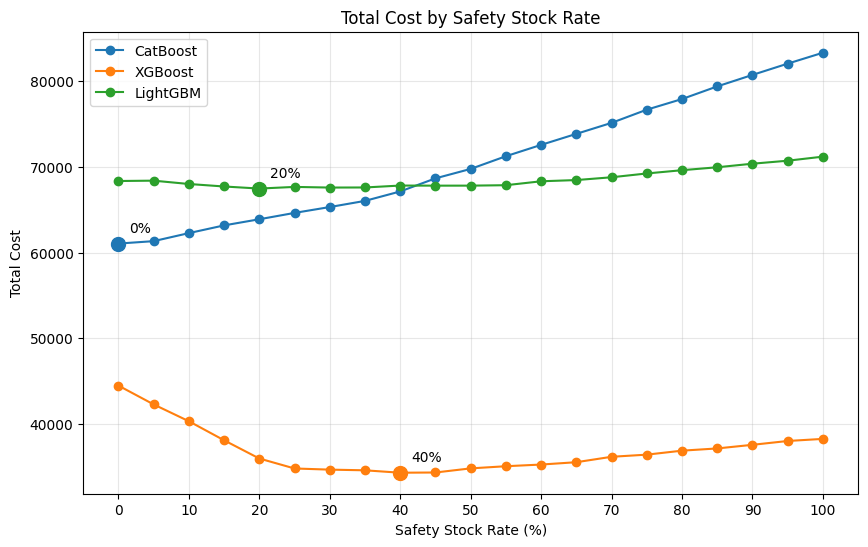

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for model_name in all_optimization_results["Model"].unique():
    model_data = all_optimization_results[
        all_optimization_results["Model"] == model_name
    ]

    plt.plot(
        model_data["SafetyStockRate"] * 100,
        model_data["TotalCost"],
        marker="o",
        label=model_name
    )

    optimal_row = model_data.loc[model_data["TotalCost"].idxmin()]

    plt.scatter(
        optimal_row["SafetyStockRate"] * 100,
        optimal_row["TotalCost"],
        s=100,
        zorder=5
    )

    plt.annotate(
        f'{optimal_row["SafetyStockRate"] * 100:.0f}%',
        (
            optimal_row["SafetyStockRate"] * 100,
            optimal_row["TotalCost"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Safety Stock Rate (%)")
plt.ylabel("Total Cost")
plt.title("Total Cost by Safety Stock Rate")
plt.xticks(range(0, 101, 10))
plt.legend()
plt.grid(alpha=0.3)

plt.show()